# Etap 5. Tabele i wykresy z coarse searchu

Notebook przygotowuje **opisową dokumentację istniejących wyników rozwojowych OOF** z pełnego classical/MLP coarse searchu. Nie uruchamia nowego treningu, ponownego CV, strojenia hiperparametrów, refinementu, confirmation ani QNN. Nie otwiera danych finalnego holdoutu 2021–2024.

Jedynym dopuszczalnym źródłem jest canonical `classical_mlp_coarse_search_manifest.json` zapisany przez frozen production runner. Osobny real-data smoke test nie jest traktowany jako coarse search ani źródło rankingu modeli.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 240)


def project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    markers = (
        Path("configs/production_experiment_runner_v1_0_0.yaml"),
        Path("src/modeling/production_runner.py"),
    )
    for candidate in (current, *current.parents):
        if all((candidate / marker).is_file() for marker in markers):
            return candidate
    raise FileNotFoundError("Nie znaleziono katalogu głównego projektu.")


ROOT = project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.modeling.coarse_search_reporting import build_coarse_search_report

# Pozostaw None przy jednym canonical runie. Gdy istnieje kilka różnych runów,
# wpisz względną ścieżkę wewnątrz repozytorium, np.
# "data/model_runs/classical_mlp_coarse_v1/classical_mlp_coarse_search_manifest.json".
MANIFEST_OVERRIDE = "data/model_runs/classical_mlp_coarse_20260820T123027Z/classical_mlp_coarse_search_manifest.json"

# Kontrola SHA-256 wszystkich zadeklarowanych OOF artifacts. Nie przelicza metryk.
VERIFY_OOF_HASHES = True
OUTPUT_DIR = ROOT / "reports/coarse_search_thesis"

ROOT

PosixPath('/Users/oskarstachowski/qnn-financial-statement-analysis')

## Definicje metryk i reguła rankingu

**Pooled OOF PR-AUC** to `average_precision_score` policzony jednorazowo po połączeniu wszystkich predykcji out-of-fold z lat walidacyjnych 2015–2020. Nie jest to średnia z PR-AUC foldów i nie wykorzystuje predykcji in-sample.

**Pooled OOF ROC-AUC** zachowuje analogiczny sposób agregacji. PR-AUC pozostaje główną metryką rankingową dla niezbalansowanej klasyfikacji, a ROC-AUC pełni funkcję uzupełniającą.

Ranking wykorzystuje frozen deterministic ranking contract repozytorium: najpierw pooled OOF PR-AUC, a pipeline-defined tie-breakers wyłącznie dla wyników równych po kontraktowej kwantyzacji. Wartości nie są zaokrąglane przed rankingiem; zaokrąglenie dotyczy tylko prezentacji.

## 5.0. Źródło danych i kontrola integralności

Poniższa komórka:

- odnajduje canonical full coarse-search manifest;
- odrzuca smoke testy i źródła syntetyczne;
- sprawdza liczbę pozycji, rodziny, warianty, duplikaty, brakujące metryki i runtime;
- kontroluje granice etapów eksperymentu;
- potwierdza istnienie i SHA-256 OOF artifacts, jeżeli są zadeklarowane;
- nie wywołuje żadnego kodu treningowego.

In [2]:
report = build_coarse_search_report(
    project_root=ROOT,
    manifest_override=MANIFEST_OVERRIDE,
    output_dir=OUTPUT_DIR,
    verify_oof_hashes=VERIFY_OOF_HASHES,
)

display(report.source_summary)
display(report.integrity_summary)
if not report.integrity_issues.empty:
    display(report.integrity_issues)
print(f"Ranking: {report.ranking_method}")
print(f"Artefakty raportowe: {report.output_dir.relative_to(ROOT)}")

,source_manifest,source_manifest_sha256,output_root,run_manifest,run_manifest_verified,mode,status,source_kind,training_seed,runtime_seconds
0,data/model_runs/classical_mlp_coarse_20260820T123027Z/classical_mlp_coarse_search_manifest.json,6d497649cb717a1a4e0970c87643fadf8275e11f056a59ec0f8b02c80b5abb58,data/model_runs/classical_mlp_coarse_20260820T123027Z,data/model_runs/classical_mlp_coarse_20260820T123027Z/run_manifest.json,True,classical_mlp_coarse_search,COMPLETE,frozen_project_train,20260818,10614.111805


,manifest,manifest_sha256,run_manifest_verified,candidate_positions,complete_candidate_positions,technically_invalid_positions,families,feature_blocks,duplicate_identities,missing_complete_metrics,missing_or_invalid_runtime,oof_artifacts_verified_or_present,oof_artifacts_missing_or_undeclared,errors,warnings
0,data/model_runs/classical_mlp_coarse_20260820T123027Z/classical_mlp_coarse_search_manifest.json,6d497649cb717a1a4e0970c87643fadf8275e11f056a59ec0f8b02c80b5abb58,True,247,238,9,"dummy_prior, fixed_l2_logistic, elastic_net_logistic, rbf_svm, hist_gradient_boosting, xgboost, random_forest, pytorch_mlp","BLOCK_AGNOSTIC, L, L+D, L+D+R",0,0,0,238,0,0,0


Ranking: frozen_model_execution_contract_v1_2_0
Artefakty raportowe: reports/coarse_search_thesis


### Inwentarz konfiguracji

Tabela pokazuje liczbę znalezionych pozycji według rodziny, wariantu i statusu technicznego. Pozycje technicznie nieważne pozostają widoczne, ale nie uczestniczą w rankingu prowizorycznych liderów.

In [3]:
display(report.inventory)

,family,feature_block,status,configurations,missing_pr_auc,missing_runtime
0,dummy_prior,BLOCK_AGNOSTIC,COMPLETE,1,0,0
1,fixed_l2_logistic,L,COMPLETE,2,0,0
2,fixed_l2_logistic,L+D,COMPLETE,2,0,0
3,fixed_l2_logistic,L+D+R,COMPLETE,2,0,0
4,elastic_net_logistic,L,COMPLETE,12,0,0
5,elastic_net_logistic,L+D,COMPLETE,12,0,0
6,elastic_net_logistic,L+D+R,COMPLETE,12,0,0
7,rbf_svm,L,COMPLETE,9,0,0
8,rbf_svm,L,FAMILY_CANDIDATE_TECHNICALLY_INVALID,3,3,0
9,rbf_svm,L+D,COMPLETE,9,0,0


## 5.3. Najlepszy wynik według rodziny modeli

Każdy wiersz reprezentuje najwyżej sklasyfikowaną kompletną konfigurację danej rodziny według tej samej frozen reguły. Różnice na wykresie są opisowe i nie są przedstawiane jako statystycznie istotne bez osobnej analizy niepewności.

,rank,family_label,configuration_id,feature_block,pooled_oof_pr_auc,pooled_oof_roc_auc,runtime_seconds,parameters_display
0,1,XGBoost,model_stage_v1__coarse__xgboost__004,L+D+R,0.411677,0.759486,7.645564,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance"": ""sqrt"", ""learning_rate"": 0.02, ""max_depth"": 2, ""min_child_weight"": 20, ""n_estimator..."
1,4,HistGradientBoosting,model_stage_v1__coarse__hist_gradient_boosting__007,L+D+R,0.407810,0.758795,9.314059,"{""imbalance"": ""none"", ""l2_regularization"": 1.0, ""learning_rate"": 0.06, ""max_features"": 1.0, ""max_iter"": 300, ""max_leaf_nodes"": 7, ""min_s..."
2,5,Random Forest,model_stage_v1__coarse__random_forest__003,L+D+R,0.407391,0.758700,174.720555,"{""criterion"": ""gini"", ""imbalance"": ""none"", ""max_depth"": 6, ""max_features"": 0.5, ""max_samples"": 1.0, ""min_samples_leaf"": 5}"
3,44,MLP (PyTorch),model_stage_v1__coarse__pytorch_mlp__epochs_200__003,L+D,0.395485,0.744943,25.965261,"{""activation"": ""relu"", ""batch_size"": 256, ""epochs"": 200, ""hidden_layer_sizes"": [64], ""imbalance"": ""sqrt"", ""learning_rate"": 0.0003, ""weig..."
4,54,SVM RBF,model_stage_v1__coarse__rbf_svm__004,L+D+R,0.393558,0.736029,21.933586,"{""C"": 1.0, ""gamma"": 0.01, ""imbalance"": ""sqrt""}"
5,113,Regresja logistyczna Elastic Net,model_stage_v1__coarse__elastic_net_logistic__003,L+D+R,0.381825,0.740134,6.563496,"{""C"": 0.01, ""imbalance"": ""sqrt"", ""l1_ratio"": 0.25}"
6,117,Regresja logistyczna fixed L2,model_stage_v1__coarse__fixed_l2_logistic__002,L+D+R,0.381655,0.738704,6.741640,"{""C"": 1.0, ""imbalance"": ""sqrt""}"
7,238,Dummy (prior),model_stage_v1__coarse__dummy_prior__001,BLOCK_AGNOSTIC,0.172283,0.462569,6.781060,"{""imbalance"": ""none"", ""strategy"": ""prior""}"


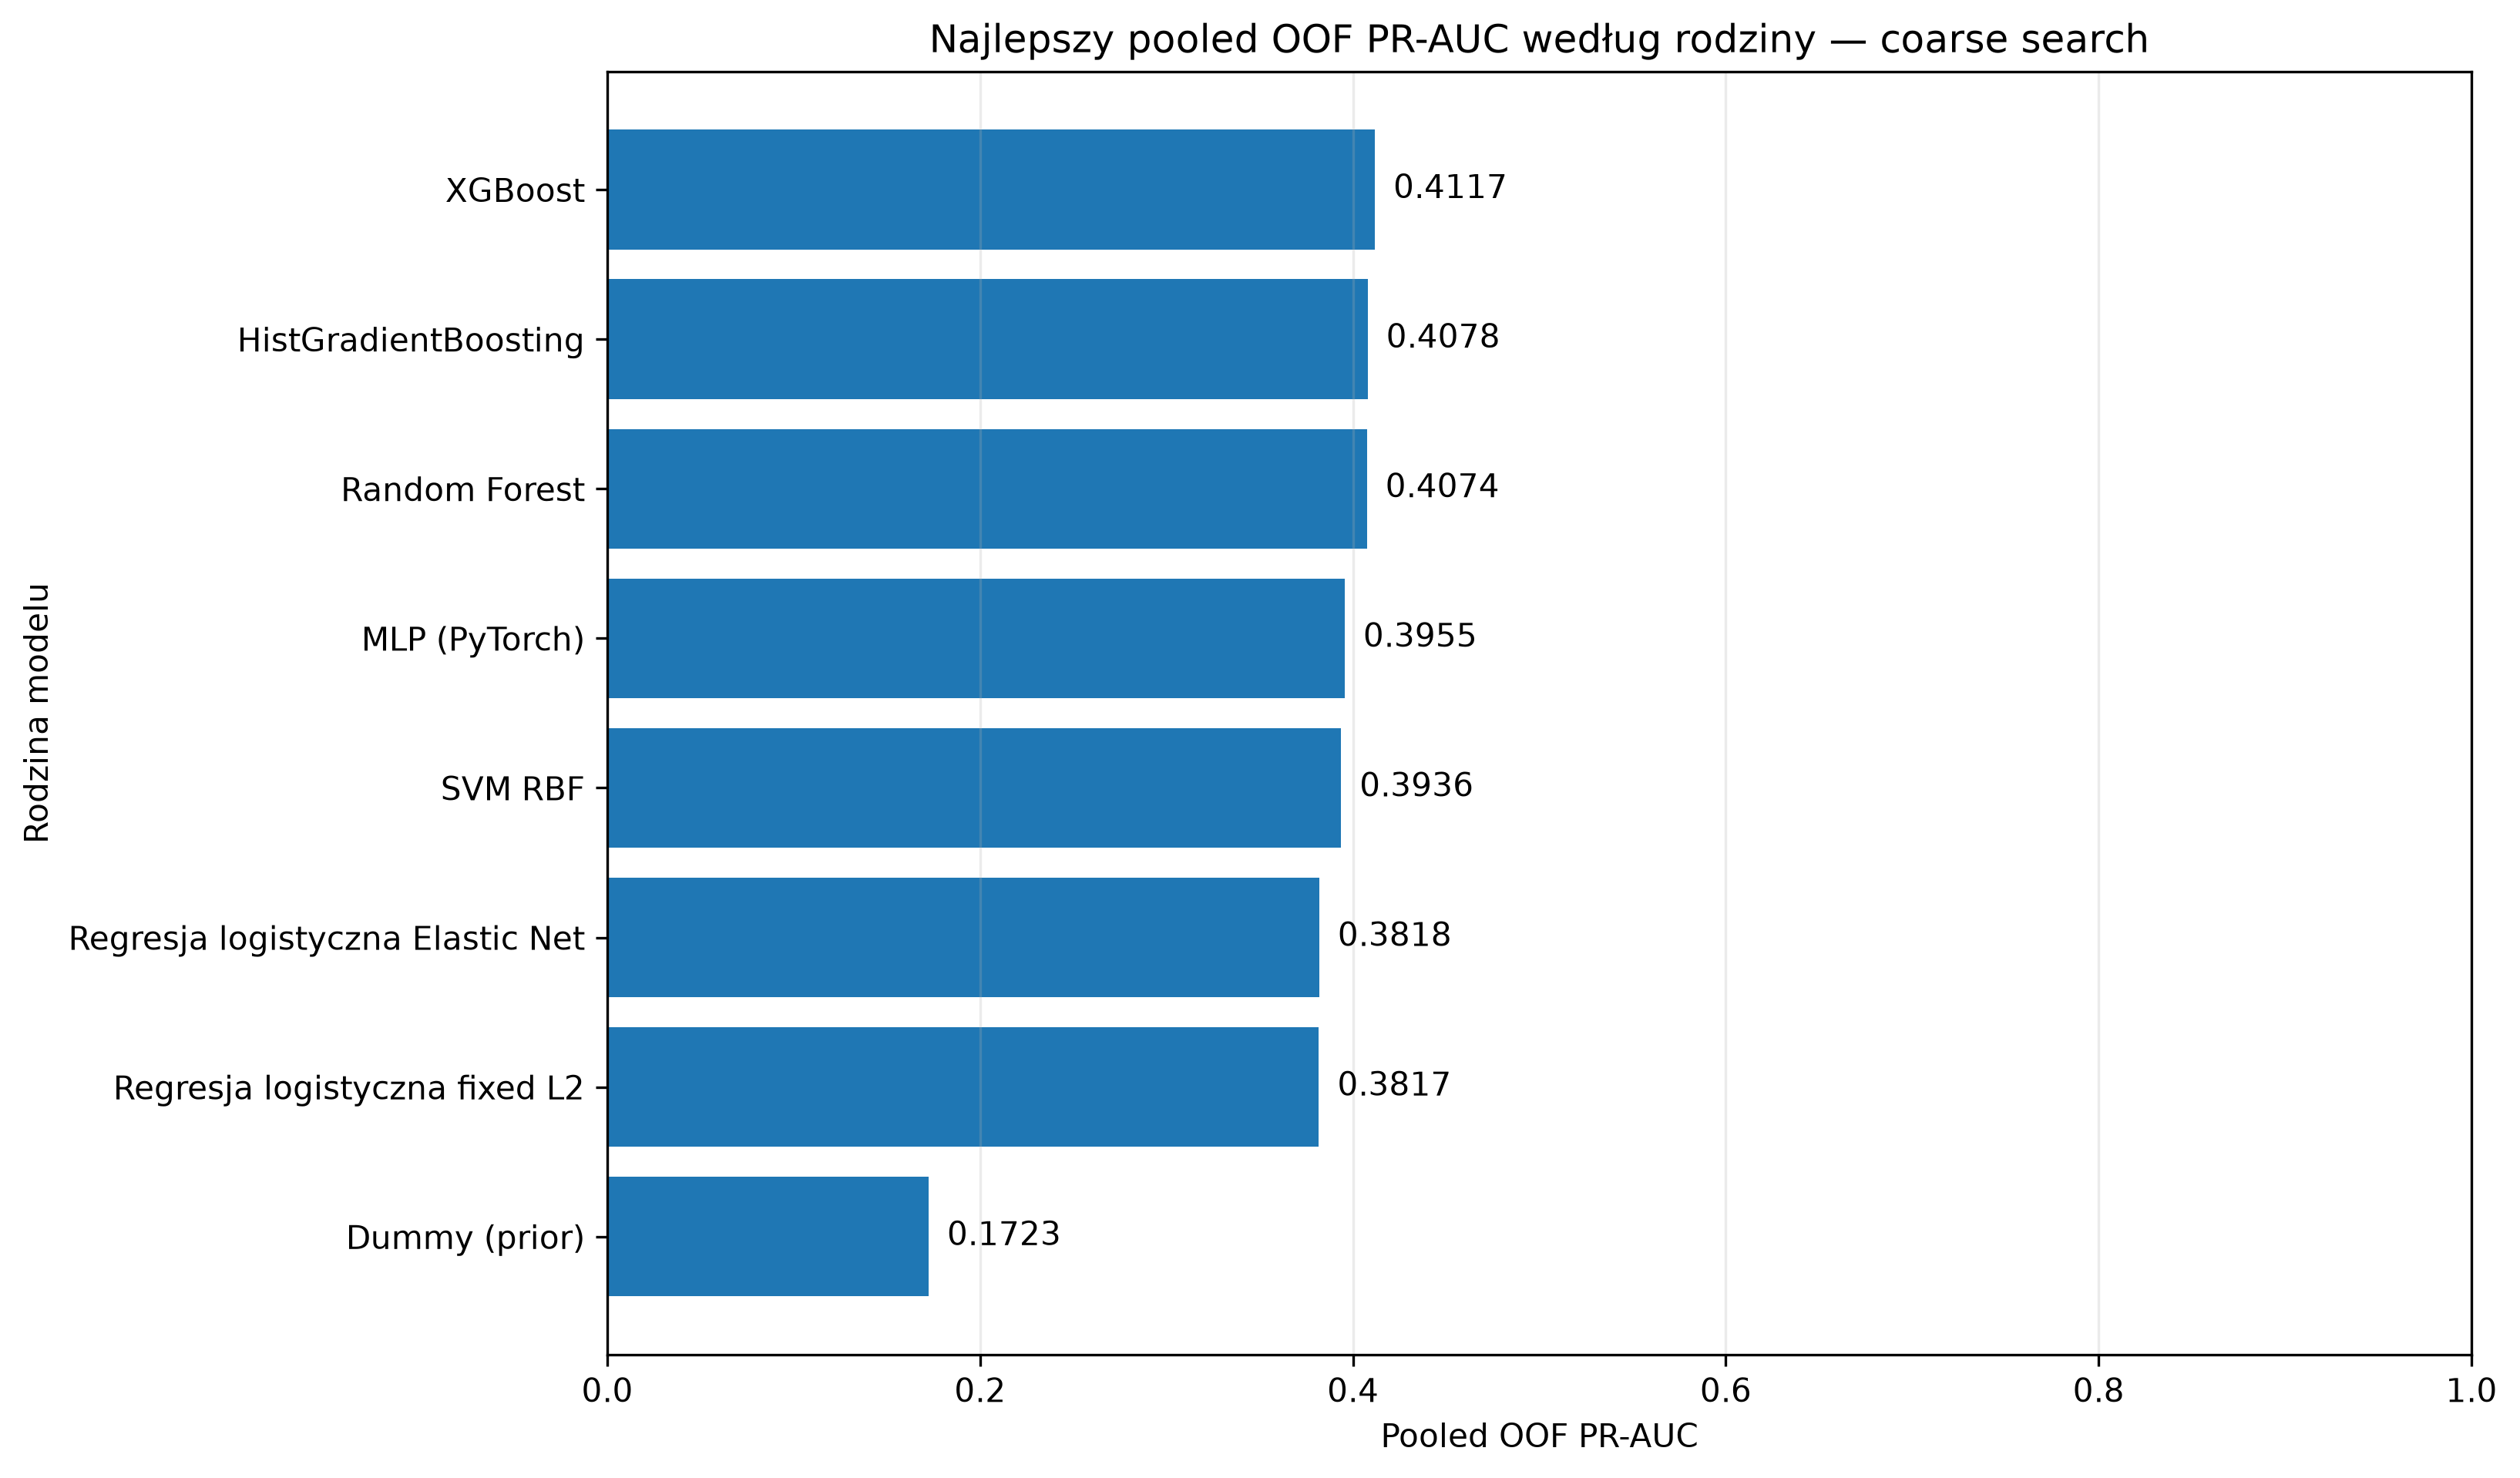

In [4]:
best_by_family = report.tables["best_by_family"]
display(
    best_by_family[
        [
            "rank", "family_label", "configuration_id", "feature_block",
            "pooled_oof_pr_auc", "pooled_oof_roc_auc", "runtime_seconds",
            "parameters_display",
        ]
    ]
)
display(Image(filename=str(report.figures["best_by_family"])))

## 5.4. Porównanie `L`, `L+D`, `L+D+R`

Znaczenie skrótów pozostaje zgodne z frozen metodologią repozytorium. Porównanie nie ma interpretacji przyczynowej: pokazuje jedynie związki pomiędzy wariantem reprezentacji, jakością OOF i kosztem obliczeniowym w istniejącym coarse searchu.

,feature_block,complete_candidates,best_family,best_family_label,best_configuration_id,best_pooled_oof_pr_auc,leader_pooled_oof_roc_auc,leader_runtime_seconds,median_pooled_oof_pr_auc,mean_pooled_oof_pr_auc,median_runtime_seconds,total_runtime_seconds
0,L,79,xgboost,XGBoost,model_stage_v1__coarse__xgboost__004,0.402720,0.754619,7.533332,0.378757,0.374996,9.969281,2419.714618
1,L+D,79,xgboost,XGBoost,model_stage_v1__coarse__xgboost__009,0.405714,0.756865,7.021008,0.380916,0.378572,15.063292,3170.368351
2,L+D+R,79,xgboost,XGBoost,model_stage_v1__coarse__xgboost__004,0.411677,0.759486,7.645564,0.383619,0.384926,16.943753,4703.938937


,family_label,feature_block,configuration_id,pooled_oof_pr_auc,pooled_oof_roc_auc,runtime_seconds,parameters_display
0,Dummy (prior),BLOCK_AGNOSTIC,model_stage_v1__coarse__dummy_prior__001,0.172283,0.462569,6.781060,"{""imbalance"": ""none"", ""strategy"": ""prior""}"
1,Regresja logistyczna fixed L2,L,model_stage_v1__coarse__fixed_l2_logistic__002,0.364977,0.733111,6.520906,"{""C"": 1.0, ""imbalance"": ""sqrt""}"
2,Regresja logistyczna fixed L2,L+D,model_stage_v1__coarse__fixed_l2_logistic__002,0.370699,0.732682,6.847885,"{""C"": 1.0, ""imbalance"": ""sqrt""}"
3,Regresja logistyczna fixed L2,L+D+R,model_stage_v1__coarse__fixed_l2_logistic__002,0.381655,0.738704,6.741640,"{""C"": 1.0, ""imbalance"": ""sqrt""}"
4,Regresja logistyczna Elastic Net,L,model_stage_v1__coarse__elastic_net_logistic__011,0.365959,0.732887,24.840897,"{""C"": 100.0, ""imbalance"": ""sqrt"", ""l1_ratio"": 0.0}"
5,Regresja logistyczna Elastic Net,L+D,model_stage_v1__coarse__elastic_net_logistic__006,0.370769,0.732943,7.057740,"{""C"": 0.1, ""imbalance"": ""sqrt"", ""l1_ratio"": 0.0}"
6,Regresja logistyczna Elastic Net,L+D+R,model_stage_v1__coarse__elastic_net_logistic__003,0.381825,0.740134,6.563496,"{""C"": 0.01, ""imbalance"": ""sqrt"", ""l1_ratio"": 0.25}"
7,SVM RBF,L,model_stage_v1__coarse__rbf_svm__006,0.371476,0.712508,19.197371,"{""C"": 1.0, ""gamma"": 0.1, ""imbalance"": ""sqrt""}"
8,SVM RBF,L+D,model_stage_v1__coarse__rbf_svm__003,0.381492,0.725193,20.421533,"{""C"": 1.0, ""gamma"": ""scale"", ""imbalance"": ""sqrt""}"
9,SVM RBF,L+D+R,model_stage_v1__coarse__rbf_svm__004,0.393558,0.736029,21.933586,"{""C"": 1.0, ""gamma"": 0.01, ""imbalance"": ""sqrt""}"


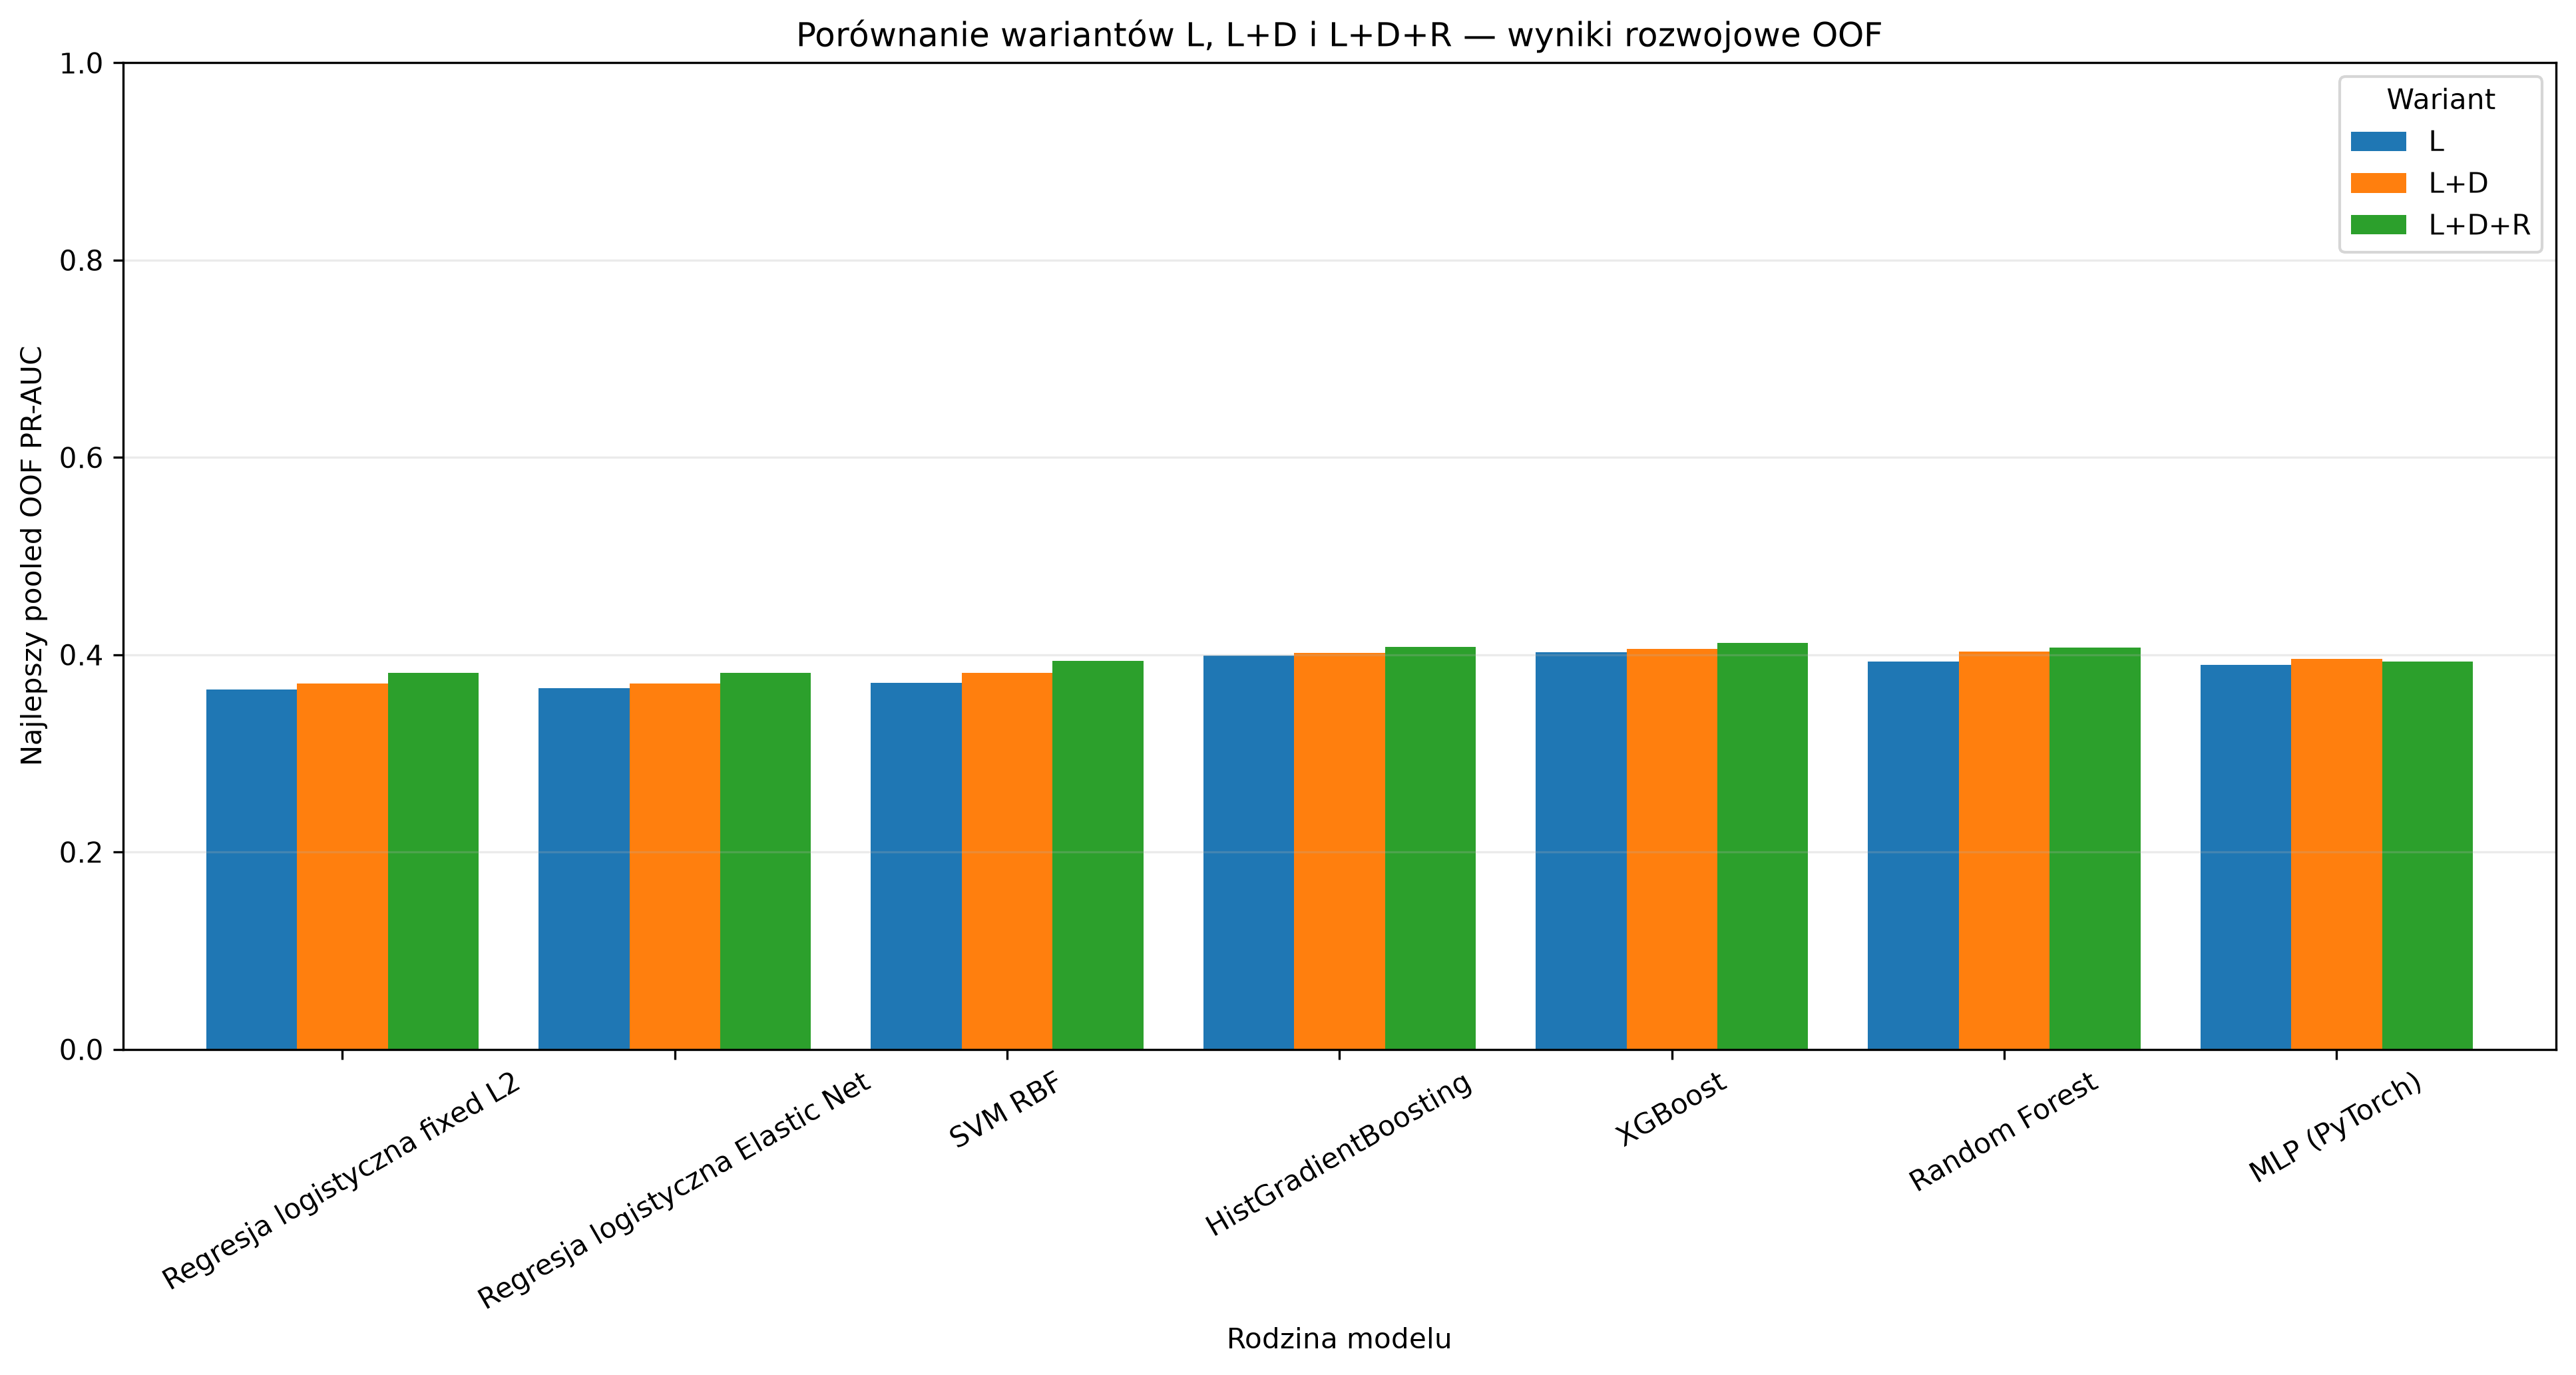

In [5]:
display(report.tables["feature_blocks_overall"])
display(
    report.tables["best_by_family_and_block"][
        [
            "family_label", "feature_block", "configuration_id",
            "pooled_oof_pr_auc", "pooled_oof_roc_auc", "runtime_seconds",
            "parameters_display",
        ]
    ]
)
display(Image(filename=str(report.figures["feature_blocks"])))

## 5.5. PR-AUC według roku 2015–2020

Wyniki roczne pochodzą z zapisanych OOF fold reports. Dla każdego roku pokazano również liczebność, liczbę obserwacji pozytywnych i udział klasy pozytywnej, ponieważ PR-AUC zależy od częstości klasy pozytywnej. Finalny holdout 2021–2024 nie jest używany.

,family_label,configuration_id,feature_block,year,n,positive_n,positive_share,pr_auc,roc_auc
0,Dummy (prior),model_stage_v1__coarse__dummy_prior__001,BLOCK_AGNOSTIC,2015,2241,506,0.225792,0.225792,0.500000
1,Dummy (prior),model_stage_v1__coarse__dummy_prior__001,BLOCK_AGNOSTIC,2016,2133,351,0.164557,0.164557,0.500000
2,Dummy (prior),model_stage_v1__coarse__dummy_prior__001,BLOCK_AGNOSTIC,2017,1549,257,0.165913,0.165913,0.500000
3,Dummy (prior),model_stage_v1__coarse__dummy_prior__001,BLOCK_AGNOSTIC,2018,1511,327,0.216413,0.216413,0.500000
4,Dummy (prior),model_stage_v1__coarse__dummy_prior__001,BLOCK_AGNOSTIC,2019,1638,326,0.199023,0.199023,0.500000
5,Dummy (prior),model_stage_v1__coarse__dummy_prior__001,BLOCK_AGNOSTIC,2020,1688,219,0.129739,0.129739,0.500000
6,Regresja logistyczna fixed L2,model_stage_v1__coarse__fixed_l2_logistic__002,L+D+R,2015,2241,506,0.225792,0.465968,0.759532
7,Regresja logistyczna fixed L2,model_stage_v1__coarse__fixed_l2_logistic__002,L+D+R,2016,2133,351,0.164557,0.379802,0.771549
8,Regresja logistyczna fixed L2,model_stage_v1__coarse__fixed_l2_logistic__002,L+D+R,2017,1549,257,0.165913,0.407660,0.779689
9,Regresja logistyczna fixed L2,model_stage_v1__coarse__fixed_l2_logistic__002,L+D+R,2018,1511,327,0.216413,0.385515,0.694156


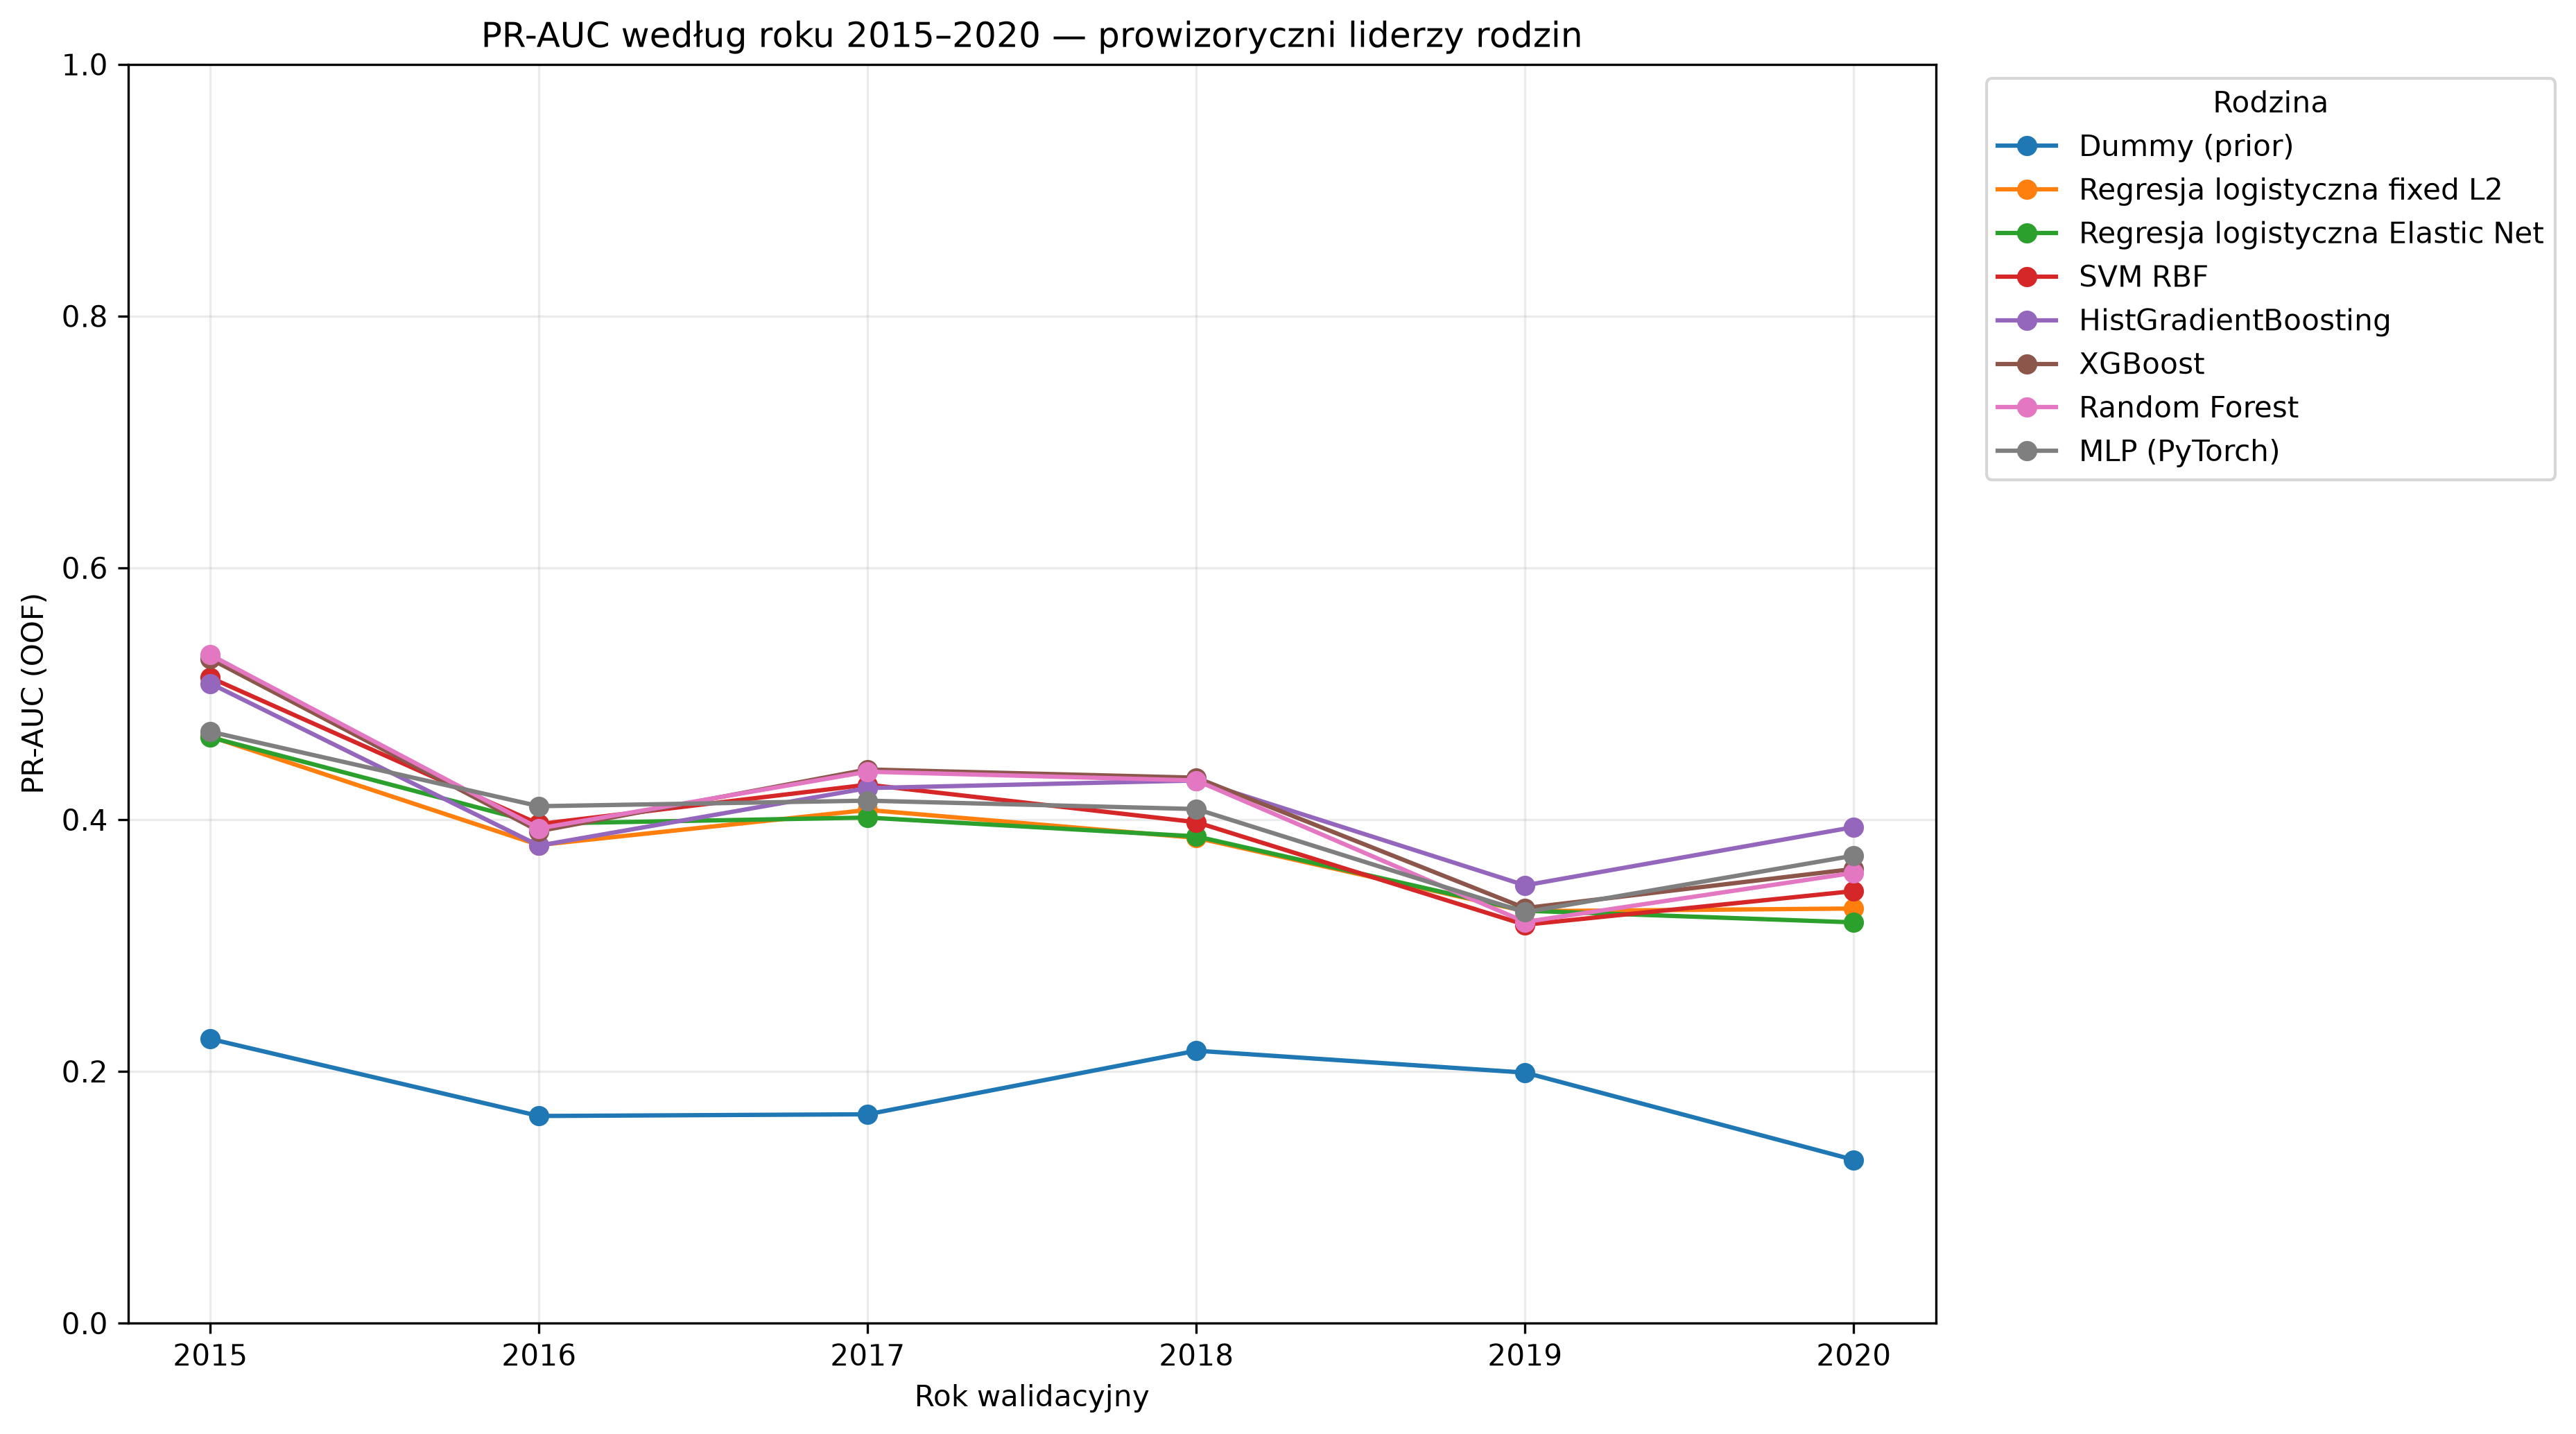

In [6]:
yearly = report.tables["yearly_pr_auc"]
display(
    yearly[
        [
            "family_label", "configuration_id", "feature_block", "year",
            "n", "positive_n", "positive_share", "pr_auc", "roc_auc",
        ]
    ]
)
display(Image(filename=str(report.figures["yearly_pr_auc"])))

## 5.6. Pooled PR-AUC vs ROC-AUC

W niezbalansowanym problemie klasyfikacyjnym wysoki ROC-AUC nie musi oznaczać równie dobrego PR-AUC. Model nie jest wybierany wyłącznie na podstawie ROC-AUC.

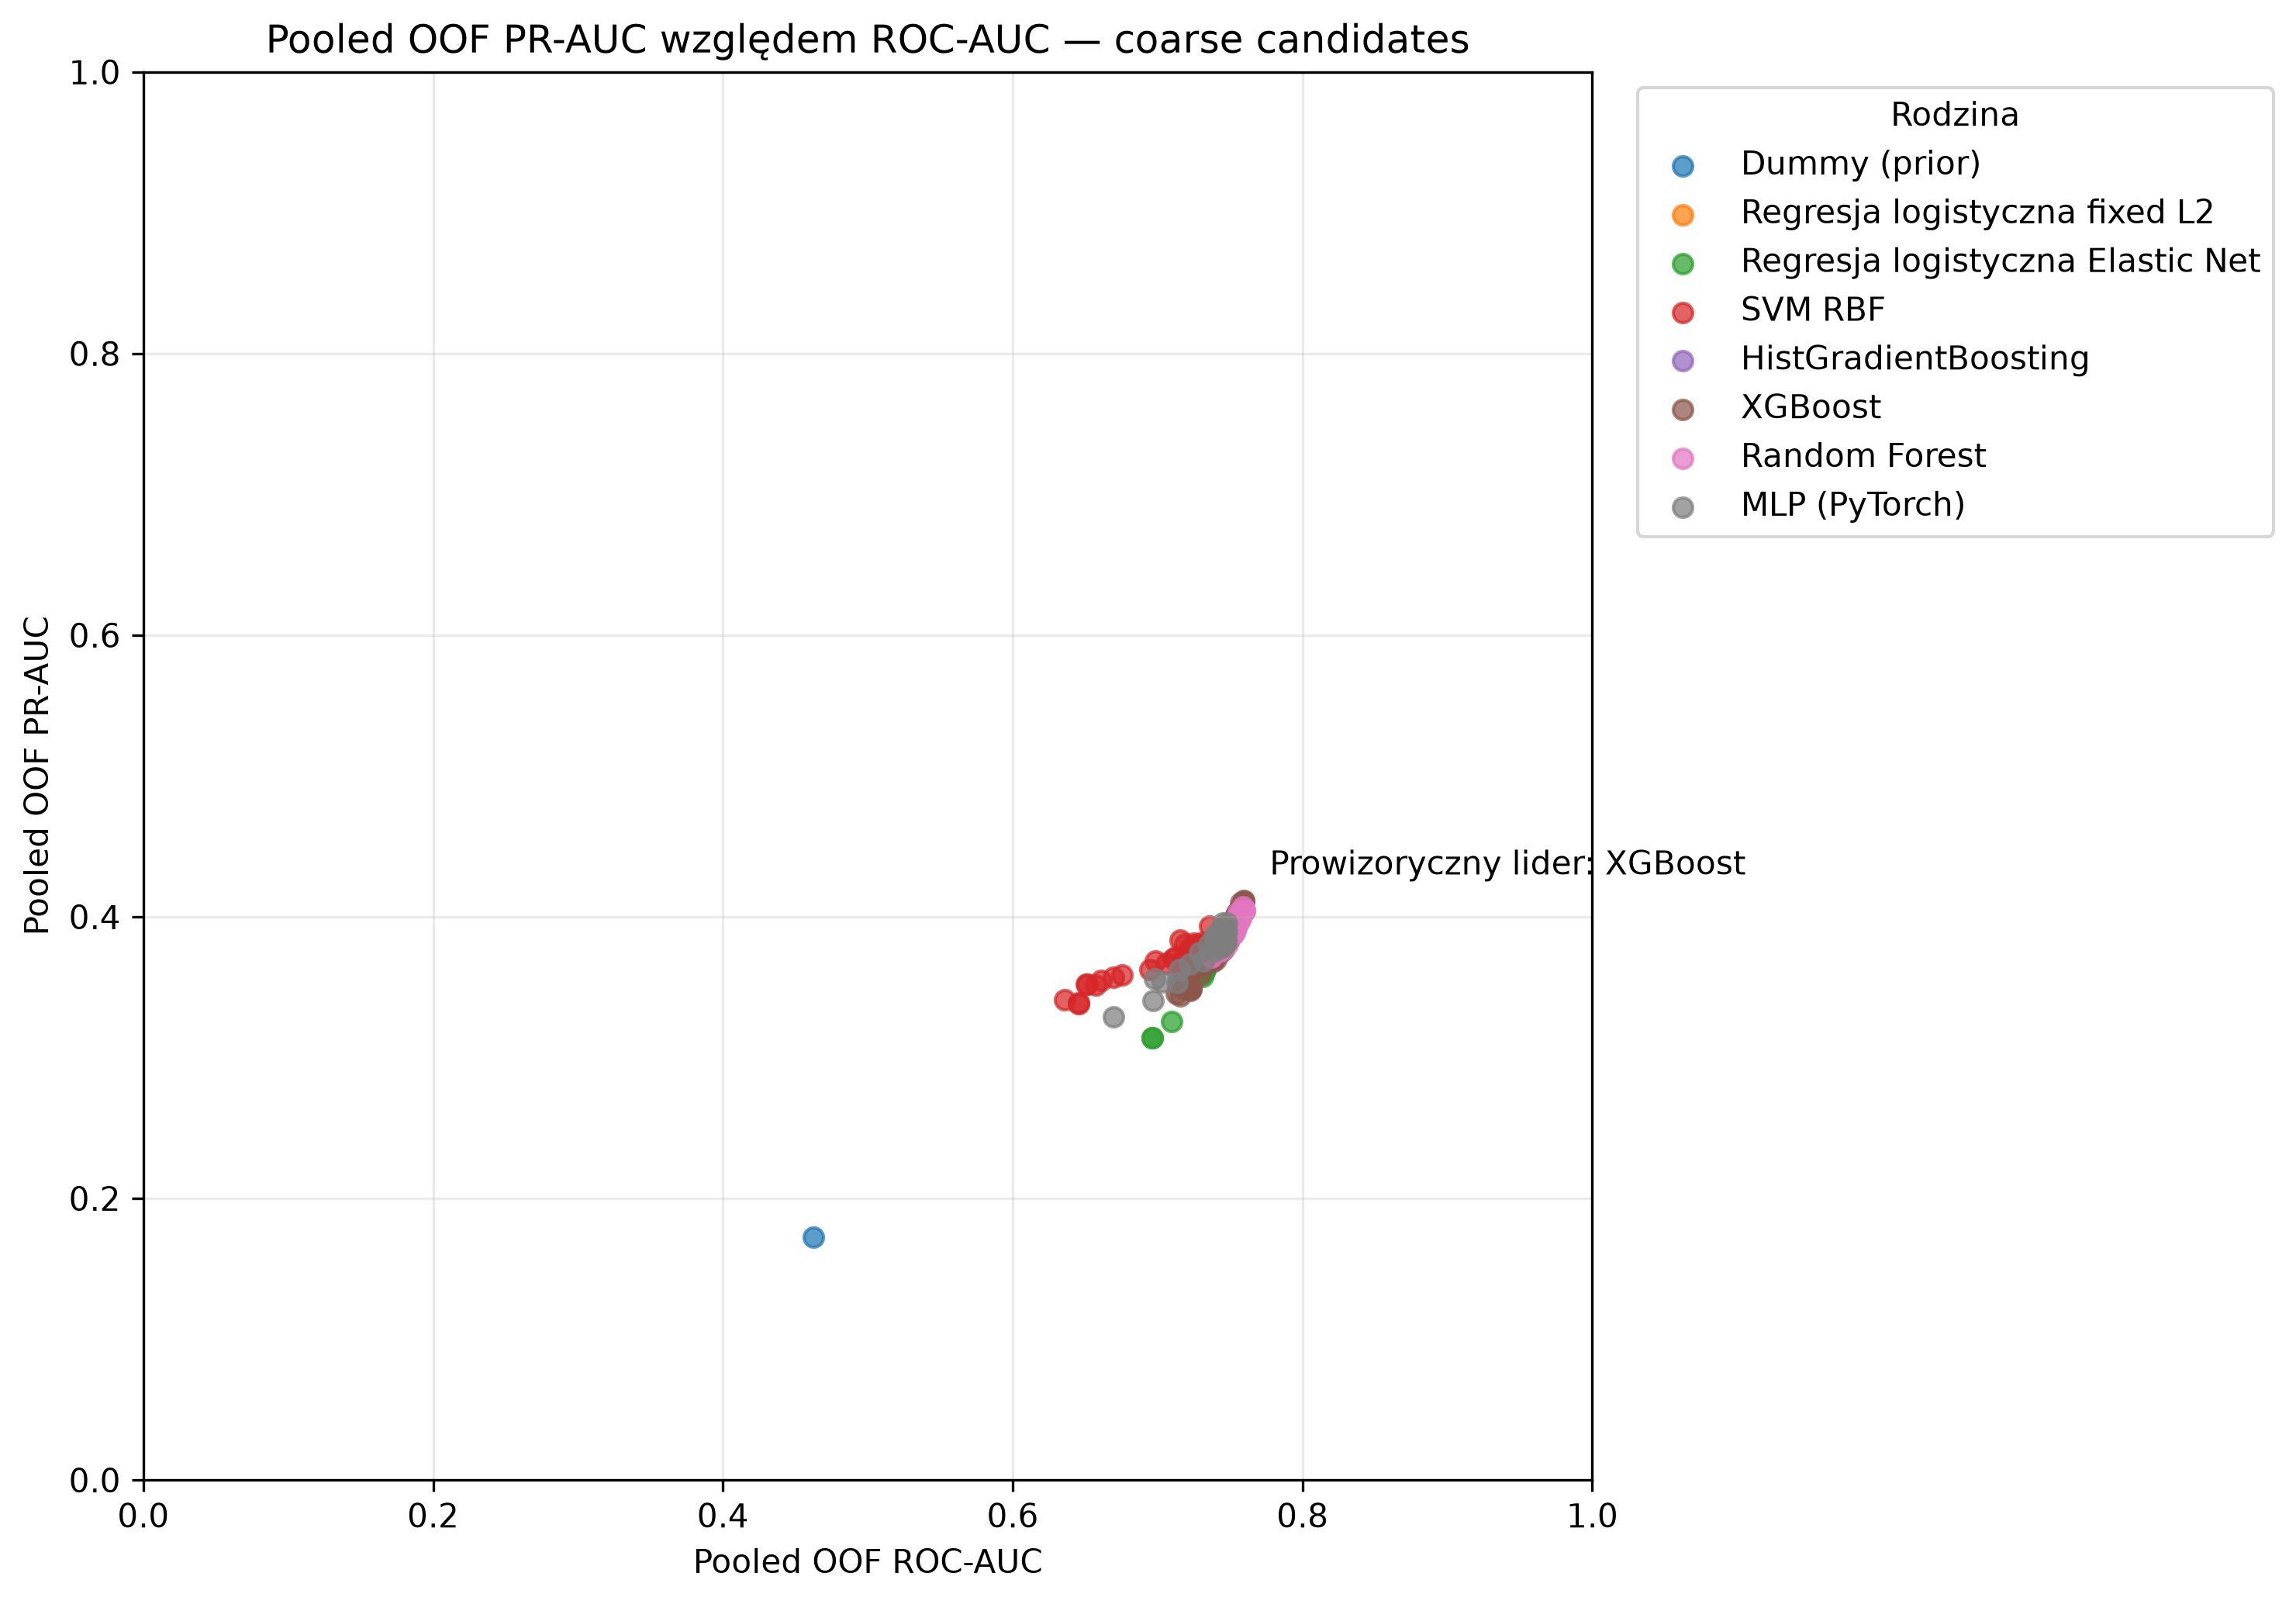

In [7]:
display(Image(filename=str(report.figures["pr_auc_vs_roc_auc"])))

## 5.7. PR-AUC względem runtime

Punkty Pareto są konfiguracjami niedominowanymi opisowo: nie istnieje inna kompletna konfiguracja, która byłaby jednocześnie co najmniej tak szybka i miała wyższy PR-AUC. Nie oznacza to automatycznego wyboru jednego „najlepszego kompromisu”.

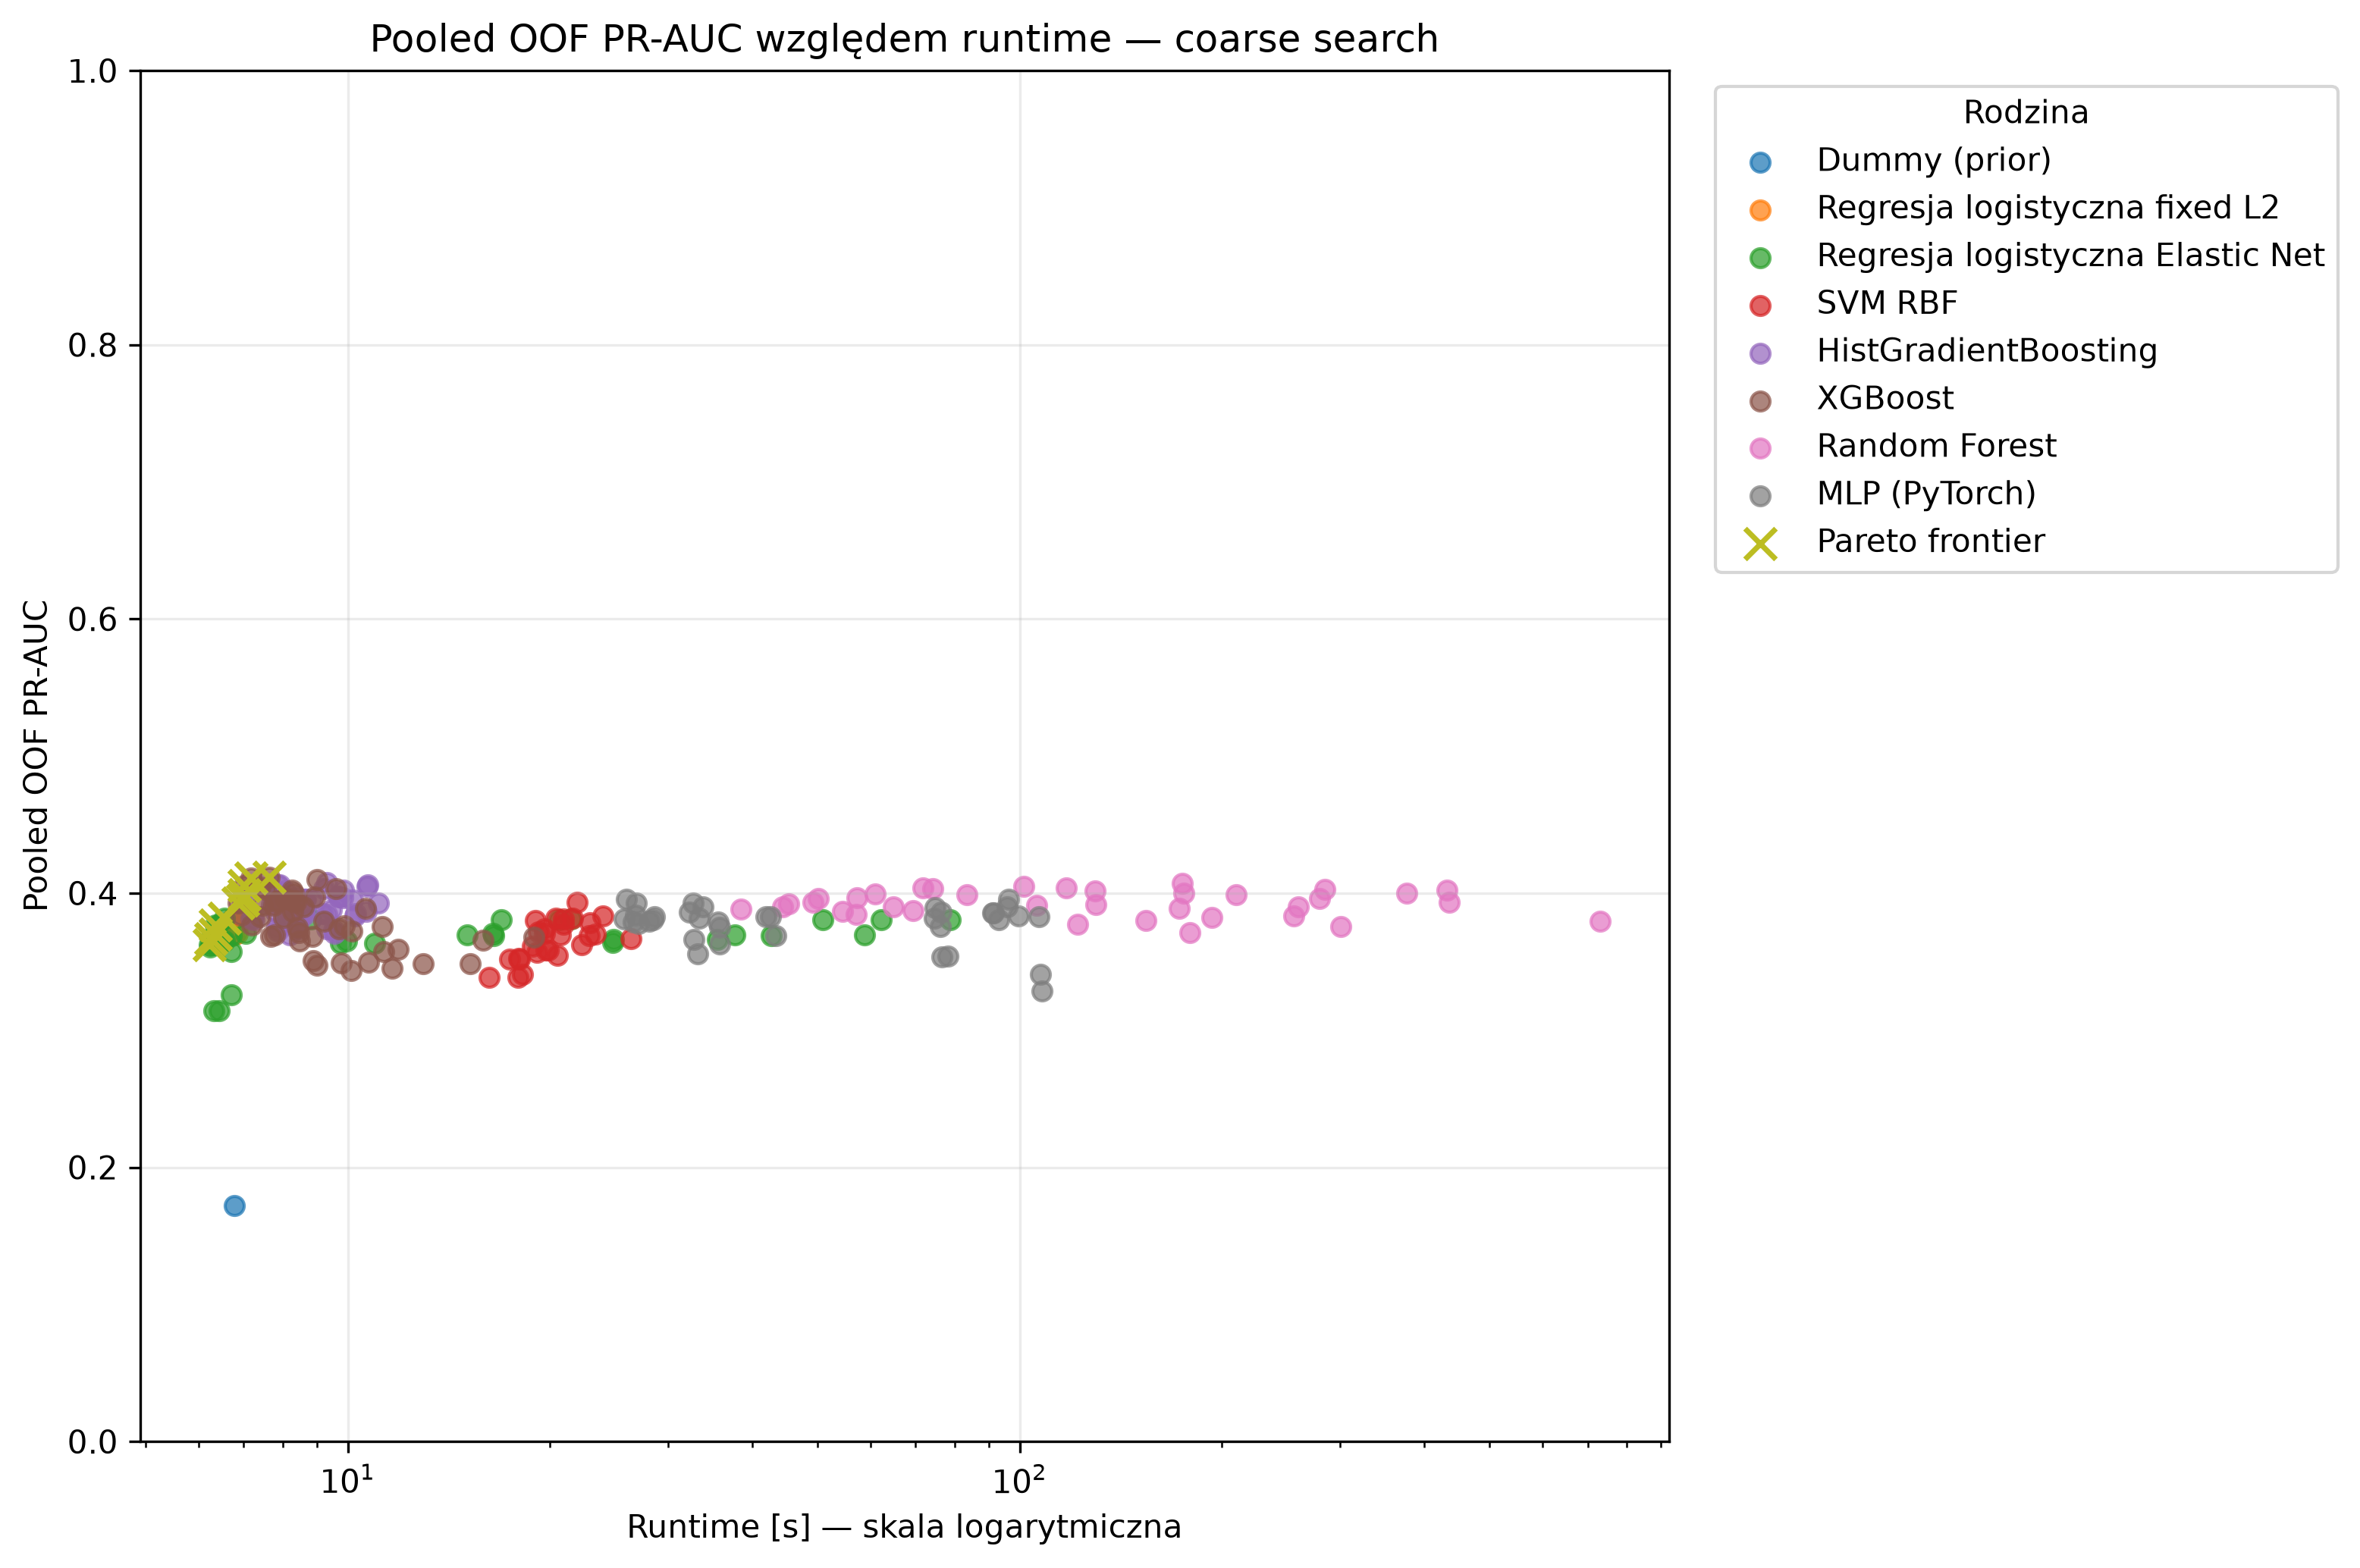

,family_label,configuration_id,feature_block,pooled_oof_pr_auc,pooled_oof_roc_auc,runtime_seconds,parameters_display
0,Regresja logistyczna Elastic Net,model_stage_v1__coarse__elastic_net_logistic__005,L,0.362201,0.731615,6.231285,"{""C"": 0.1, ""imbalance"": ""none"", ""l1_ratio"": 1.0}"
1,Regresja logistyczna Elastic Net,model_stage_v1__coarse__elastic_net_logistic__004,L+D,0.366874,0.734108,6.259912,"{""C"": 0.01, ""imbalance"": ""sqrt"", ""l1_ratio"": 1.0}"
2,Regresja logistyczna Elastic Net,model_stage_v1__coarse__elastic_net_logistic__003,L+D,0.369887,0.733943,6.353609,"{""C"": 0.01, ""imbalance"": ""sqrt"", ""l1_ratio"": 0.25}"
3,Regresja logistyczna Elastic Net,model_stage_v1__coarse__elastic_net_logistic__004,L+D+R,0.376612,0.739399,6.355599,"{""C"": 0.01, ""imbalance"": ""sqrt"", ""l1_ratio"": 1.0}"
4,Regresja logistyczna Elastic Net,model_stage_v1__coarse__elastic_net_logistic__003,L+D+R,0.381825,0.740134,6.563496,"{""C"": 0.01, ""imbalance"": ""sqrt"", ""l1_ratio"": 0.25}"
5,XGBoost,model_stage_v1__coarse__xgboost__009,L,0.393006,0.753837,6.864126,"{""colsample_bytree"": 0.7, ""gamma"": 0.1, ""imbalance"": ""sqrt"", ""learning_rate"": 0.05, ""max_depth"": 3, ""min_child_weight"": 1, ""n_estimators..."
6,HistGradientBoosting,model_stage_v1__coarse__hist_gradient_boosting__004,L,0.395237,0.751770,6.981360,"{""imbalance"": ""none"", ""l2_regularization"": 0.1, ""learning_rate"": 0.1, ""max_features"": 0.7, ""max_iter"": 150, ""max_leaf_nodes"": 7, ""min_sa..."
7,HistGradientBoosting,model_stage_v1__coarse__hist_gradient_boosting__005,L,0.398836,0.754019,7.014438,"{""imbalance"": ""none"", ""l2_regularization"": 1.0, ""learning_rate"": 0.06, ""max_features"": 0.7, ""max_iter"": 150, ""max_leaf_nodes"": 7, ""min_s..."
8,XGBoost,model_stage_v1__coarse__xgboost__009,L+D,0.405714,0.756865,7.021008,"{""colsample_bytree"": 0.7, ""gamma"": 0.1, ""imbalance"": ""sqrt"", ""learning_rate"": 0.05, ""max_depth"": 3, ""min_child_weight"": 1, ""n_estimators..."
9,XGBoost,model_stage_v1__coarse__xgboost__009,L+D+R,0.410889,0.759359,7.183284,"{""colsample_bytree"": 0.7, ""gamma"": 0.1, ""imbalance"": ""sqrt"", ""learning_rate"": 0.05, ""max_depth"": 3, ""min_child_weight"": 1, ""n_estimators..."


In [8]:
display(Image(filename=str(report.figures["pr_auc_vs_runtime"])))
display(
    report.tables["pareto_frontier"][
        [
            "family_label", "configuration_id", "feature_block",
            "pooled_oof_pr_auc", "pooled_oof_roc_auc", "runtime_seconds",
            "parameters_display",
        ]
    ]
)

## 5.8. Top 20 coarse candidates

Ranking wykorzystuje pełną precyzję źródłowych metryk. Zaokrąglenie widoczne w interfejsie notebooka nie wpływa na kolejność.

In [9]:
top20 = report.tables["top20"]
display(
    top20[
        [
            "rank", "family_label", "configuration_id", "feature_block",
            "pooled_oof_pr_auc", "pooled_oof_roc_auc", "runtime_seconds",
            "parameters_display",
        ]
    ]
)

,rank,family_label,configuration_id,feature_block,pooled_oof_pr_auc,pooled_oof_roc_auc,runtime_seconds,parameters_display
0,1,XGBoost,model_stage_v1__coarse__xgboost__004,L+D+R,0.411677,0.759486,7.645564,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance"": ""sqrt"", ""learning_rate"": 0.02, ""max_depth"": 2, ""min_child_weight"": 20, ""n_estimator..."
1,2,XGBoost,model_stage_v1__coarse__xgboost__009,L+D+R,0.410889,0.759359,7.183284,"{""colsample_bytree"": 0.7, ""gamma"": 0.1, ""imbalance"": ""sqrt"", ""learning_rate"": 0.05, ""max_depth"": 3, ""min_child_weight"": 1, ""n_estimators..."
2,3,XGBoost,model_stage_v1__coarse__xgboost__005,L+D+R,0.410009,0.757408,9.001706,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance"": ""sqrt"", ""learning_rate"": 0.05, ""max_depth"": 2, ""min_child_weight"": 5, ""n_estimators..."
3,4,HistGradientBoosting,model_stage_v1__coarse__hist_gradient_boosting__007,L+D+R,0.407810,0.758795,9.314059,"{""imbalance"": ""none"", ""l2_regularization"": 1.0, ""learning_rate"": 0.06, ""max_features"": 1.0, ""max_iter"": 300, ""max_leaf_nodes"": 7, ""min_s..."
4,5,Random Forest,model_stage_v1__coarse__random_forest__003,L+D+R,0.407391,0.758700,174.720555,"{""criterion"": ""gini"", ""imbalance"": ""none"", ""max_depth"": 6, ""max_features"": 0.5, ""max_samples"": 1.0, ""min_samples_leaf"": 5}"
5,6,HistGradientBoosting,model_stage_v1__coarse__hist_gradient_boosting__010,L+D+R,0.406121,0.758691,10.703687,"{""imbalance"": ""none"", ""l2_regularization"": 10.0, ""learning_rate"": 0.03, ""max_features"": 0.7, ""max_iter"": 300, ""max_leaf_nodes"": 15, ""min..."
6,7,HistGradientBoosting,model_stage_v1__coarse__hist_gradient_boosting__004,L+D+R,0.405856,0.757347,7.856317,"{""imbalance"": ""none"", ""l2_regularization"": 0.1, ""learning_rate"": 0.1, ""max_features"": 0.7, ""max_iter"": 150, ""max_leaf_nodes"": 7, ""min_sa..."
7,8,HistGradientBoosting,model_stage_v1__coarse__hist_gradient_boosting__005,L+D+R,0.405841,0.758947,7.917692,"{""imbalance"": ""none"", ""l2_regularization"": 1.0, ""learning_rate"": 0.06, ""max_features"": 0.7, ""max_iter"": 150, ""max_leaf_nodes"": 7, ""min_s..."
8,9,XGBoost,model_stage_v1__coarse__xgboost__009,L+D,0.405714,0.756865,7.021008,"{""colsample_bytree"": 0.7, ""gamma"": 0.1, ""imbalance"": ""sqrt"", ""learning_rate"": 0.05, ""max_depth"": 3, ""min_child_weight"": 1, ""n_estimators..."
9,10,HistGradientBoosting,model_stage_v1__coarse__hist_gradient_boosting__016,L+D+R,0.404982,0.755986,10.682879,"{""imbalance"": ""sqrt"", ""l2_regularization"": 1.0, ""learning_rate"": 0.03, ""max_features"": 0.7, ""max_iter"": 300, ""max_leaf_nodes"": 15, ""min_..."


## 5.9. Porównanie z baseline'ami

Podstawowym wynikiem pozostaje bezwzględna różnica PR-AUC. Przewaga nad baseline'em nie jest określana jako dowód istotności statystycznej bez odpowiedniej analizy niepewności.

In [10]:
display(
    report.tables["baseline_comparison"][
        [
            "role", "family_label", "configuration_id", "feature_block",
            "pooled_oof_pr_auc", "pooled_oof_roc_auc", "runtime_seconds",
            "delta_pr_auc_vs_dummy", "delta_pr_auc_vs_fixed_l2",
        ]
    ]
)

,role,family_label,configuration_id,feature_block,pooled_oof_pr_auc,pooled_oof_roc_auc,runtime_seconds,delta_pr_auc_vs_dummy,delta_pr_auc_vs_fixed_l2
0,prowizoryczny lider rodziny: XGBoost; top coarse candidate,XGBoost,model_stage_v1__coarse__xgboost__004,L+D+R,0.411677,0.759486,7.645564,0.239394,0.030023
1,prowizoryczny lider rodziny: HistGradientBoosting,HistGradientBoosting,model_stage_v1__coarse__hist_gradient_boosting__007,L+D+R,0.407810,0.758795,9.314059,0.235527,0.026155
2,prowizoryczny lider rodziny: Random Forest,Random Forest,model_stage_v1__coarse__random_forest__003,L+D+R,0.407391,0.758700,174.720555,0.235108,0.025736
3,prowizoryczny lider rodziny: MLP (PyTorch),MLP (PyTorch),model_stage_v1__coarse__pytorch_mlp__epochs_200__003,L+D,0.395485,0.744943,25.965261,0.223201,0.013830
4,prowizoryczny lider rodziny: SVM RBF,SVM RBF,model_stage_v1__coarse__rbf_svm__004,L+D+R,0.393558,0.736029,21.933586,0.221275,0.011903
5,prowizoryczny lider rodziny: Regresja logistyczna Elastic Net,Regresja logistyczna Elastic Net,model_stage_v1__coarse__elastic_net_logistic__003,L+D+R,0.381825,0.740134,6.563496,0.209542,0.000170
6,fixed L2 logistic; prowizoryczny lider rodziny: Regresja logistyczna fixed L2,Regresja logistyczna fixed L2,model_stage_v1__coarse__fixed_l2_logistic__002,L+D+R,0.381655,0.738704,6.741640,0.209372,0.000000
7,Dummy; prowizoryczny lider rodziny: Dummy (prior),Dummy (prior),model_stage_v1__coarse__dummy_prior__001,BLOCK_AGNOSTIC,0.172283,0.462569,6.781060,0.000000,-0.209372


## 5.10. Zwarta tabela do pracy magisterskiej

Statusy są celowo ostrożne: `baseline`, `prowizoryczny lider rodziny` lub `kandydat do refinementu`. Nie używa się określeń sugerujących ostateczny wynik całego badania.

In [11]:
display(report.tables["thesis_family_summary"])

,Rodzina,Wariant,Pooled OOF PR-AUC,ROC-AUC,Runtime [s],Status,configuration_id
0,XGBoost,L+D+R,0.411677,0.759486,7.645564,kandydat do refinementu,model_stage_v1__coarse__xgboost__004
1,HistGradientBoosting,L+D+R,0.407810,0.758795,9.314059,kandydat do refinementu,model_stage_v1__coarse__hist_gradient_boosting__007
2,Random Forest,L+D+R,0.407391,0.758700,174.720555,kandydat do refinementu,model_stage_v1__coarse__random_forest__003
3,MLP (PyTorch),L+D,0.395485,0.744943,25.965261,prowizoryczny lider rodziny,model_stage_v1__coarse__pytorch_mlp__epochs_200__003
4,SVM RBF,L+D+R,0.393558,0.736029,21.933586,prowizoryczny lider rodziny,model_stage_v1__coarse__rbf_svm__004
5,Regresja logistyczna Elastic Net,L+D+R,0.381825,0.740134,6.563496,prowizoryczny lider rodziny,model_stage_v1__coarse__elastic_net_logistic__003
6,Regresja logistyczna fixed L2,L+D+R,0.381655,0.738704,6.741640,baseline,model_stage_v1__coarse__fixed_l2_logistic__002
7,Dummy (prior),BLOCK_AGNOSTIC,0.172283,0.462569,6.781060,baseline,model_stage_v1__coarse__dummy_prior__001


## Podsumowanie opisowe i reprodukowalność

Wszystkie tabele są zapisane jako CSV oraz Markdown, wykresy jako PNG 300 DPI i SVG, a `analysis_manifest.json` rejestruje źródłowy SHA-256, metodę rankingu i wygenerowane pliki. Źródłowe dane i wyniki nie są modyfikowane.

In [12]:
display(Markdown(report.summary_markdown))
print(f"Manifest analizy: {report.analysis_manifest_path.relative_to(ROOT)}")
print("Model fitting performed: False")
print("Protected 2021–2024 holdout opened: False")

# Podsumowanie wyników rozwojowych OOF

W coarse searchu najwyższy pooled OOF PR-AUC uzyskał **XGBoost** w wariancie **L+D+R** (configuration_id: `model_stage_v1__coarse__xgboost__004`): **0.411677**. Jest to prowizoryczny lider klasycznej/MLP części coarse searchu; wynik nie jest finalny.

Bezwzględna przewaga PR-AUC nad Dummy wynosi **0.239394**, a nad najlepszym fixed L2 logistic **0.030023**. Różnice te nie są automatycznie dowodem istotności statystycznej.

Dla prowizorycznego lidera roczny PR-AUC w latach 2015–2020 mieści się od **0.329695** do **0.527709** (rozstęp **0.198014**). Jest to opis zmienności między latami; bez osobnej analizy niepewności nie należy nadawać mu interpretacji testu stabilności.

Pareto frontier jakość–runtime obejmuje **11** konfiguracji. Prowizoryczny lider znajduje się na tej granicy. Nie wyznaczono arbitralnego jednego „najlepszego kompromisu”.

Do dalszego refinementu zgodnie z zapisanym manifestem kwalifikują się: **XGBoost, HistGradientBoosting, Random Forest**.

Wyników nie należy traktować jako finalnych: refinement, confirmation seeds i QNN należą do kolejnych etapów, a finalny holdout 2021–2024 nie jest używany w tej analizie.


Manifest analizy: reports/coarse_search_thesis/analysis_manifest.json
Model fitting performed: False
Protected 2021–2024 holdout opened: False
